In [1]:
import pandas as pd
import numpy as np
import re
import string
import pickle
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import nltk
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dohan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dohan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
data = pd.read_csv('berita_kompas_sample.csv')
data

,No,Judul Berita,Isi Berita,Tanggal Berita,Kategori Berita
0,1,Banyak Serangga Keluar dari Tempat Pengembalia...,"DETROIT, KOMPAS.com - Sebuah perpustakaan di p...",25/09/2024,global
1,2,Benarkah Petir Bisa Menyambar Lebih dari Sekal...,KOMPAS.com - Unggahan di media sosial menyebut...,25/09/2024,tren
2,3,Studi: Dampak Jangka Panjang Covid-19 pada Ota...,"KOMPAS.com - Penelitian baru mengungkapkan, or...",25/09/2024,tren
3,4,"Bukan Sunita Williams, Ini 2 Astronot yang Tin...",KOMPAS.com - Dua astronot Badan Penerbangan da...,25/09/2024,tren
4,5,"Balas Serangan Israel, Hizbullah Klaim Tembakk...",KOMPAS.com - Kelompok Hizbullah mengeklaim ber...,25/09/2024,tren
...,...,...,...,...,...
195,196,Angkatan Laut AS Minta Maaf atas Penghancuran ...,"WASHINGTON DC, KOMPAS.com - Dalam sebuah upaca...",22/09/2024,global
196,197,Polisi Malaysia Tangkap 355 Orang terkait Kasu...,"KUALA LUMPUR, KOMPAS.com - Polisi Malaysia men...",22/09/2024,global
197,198,Rangkuman Hari Ke-941 Serangan Rusia ke Ukrain...,"KYIV, KOMPAS.com - Masih ada beberapa hal baru...",22/09/2024,global
198,199,Bujuk Rayu Zelensky pada Biden Jelang Berakhir...,"KYIV, KOMPAS.com - Volodymyr Zelensky mendesak...",22/09/2024,global


In [4]:
# Text Preprocessing Functions
def casefolding(text):
    return text.lower()

def cleansing(text):
    text = text.strip()
    text = re.sub(f"[{string.punctuation}]", '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"\b[a-zA-Z]\b", "", text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def word_tokenize_wrapper(text):
    return word_tokenize(text)

stop_words = set(stopwords.words('indonesian'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Stemming with Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

In [5]:
data['Cleansing'] = data['Isi Berita'].apply(casefolding).apply(cleansing)
data['tokenized_text'] = data['Cleansing'].apply(word_tokenize_wrapper)
data['no_stopwords_text'] = data['tokenized_text'].apply(remove_stopwords)
data['stemmed_text'] = data['no_stopwords_text'].apply(stem_text)
data['final_text'] = data['stemmed_text'].apply(lambda x: ' '.join(x))

In [6]:
# Menampilkan beberapa baris pertama dari setiap kolom yang telah dihasilkan
data[['Isi Berita', 'Cleansing', 'tokenized_text', 'no_stopwords_text', 'stemmed_text', 'final_text']].head()

,Isi Berita,Cleansing,tokenized_text,no_stopwords_text,stemmed_text,final_text
0,"DETROIT, KOMPAS.com - Sebuah perpustakaan di p...",detroit kompascom sebuah perpustakaan di pingg...,"[detroit, kompascom, sebuah, perpustakaan, di,...","[detroit, kompascom, perpustakaan, pinggiran, ...","[detroit, kompascom, pustaka, pinggir, kota, d...",detroit kompascom pustaka pinggir kota detroit...
1,KOMPAS.com - Unggahan di media sosial menyebut...,kompascom unggahan di media sosial menyebut pe...,"[kompascom, unggahan, di, media, sosial, menye...","[kompascom, unggahan, media, sosial, menyebut,...","[kompascom, unggah, media, sosial, sebut, peti...",kompascom unggah media sosial sebut petir samb...
2,"KOMPAS.com - Penelitian baru mengungkapkan, or...",kompascompenelitian baru mengungkapkan orang y...,"[kompascompenelitian, baru, mengungkapkan, ora...","[kompascompenelitian, orang, dirawat, rumah, s...","[kompascompenelitian, orang, rawat, rumah, sak...",kompascompenelitian orang rawat rumah sakit in...
3,KOMPAS.com - Dua astronot Badan Penerbangan da...,kompascom dua astronot badan penerbangan dan a...,"[kompascom, dua, astronot, badan, penerbangan,...","[kompascom, astronot, badan, penerbangan, anta...","[kompascom, astronot, badan, terbang, antariks...",kompascom astronot badan terbang antariksa ame...
4,KOMPAS.com - Kelompok Hizbullah mengeklaim ber...,kompascom kelompok hizbullah mengeklaim berhas...,"[kompascom, kelompok, hizbullah, mengeklaim, b...","[kompascom, kelompok, hizbullah, mengeklaim, b...","[kompascom, kelompok, hizbullah, klaim, hasil,...",kompascom kelompok hizbullah klaim hasil seran...


In [7]:
# Menghapus kolom kategori langsung dari DataFrame asli
data.drop(columns=['Kategori Berita'], inplace=True)
data.head()

,No,Judul Berita,Isi Berita,Tanggal Berita,Cleansing,tokenized_text,no_stopwords_text,stemmed_text,final_text
0,1,Banyak Serangga Keluar dari Tempat Pengembalia...,"DETROIT, KOMPAS.com - Sebuah perpustakaan di p...",25/09/2024,detroit kompascom sebuah perpustakaan di pingg...,"[detroit, kompascom, sebuah, perpustakaan, di,...","[detroit, kompascom, perpustakaan, pinggiran, ...","[detroit, kompascom, pustaka, pinggir, kota, d...",detroit kompascom pustaka pinggir kota detroit...
1,2,Benarkah Petir Bisa Menyambar Lebih dari Sekal...,KOMPAS.com - Unggahan di media sosial menyebut...,25/09/2024,kompascom unggahan di media sosial menyebut pe...,"[kompascom, unggahan, di, media, sosial, menye...","[kompascom, unggahan, media, sosial, menyebut,...","[kompascom, unggah, media, sosial, sebut, peti...",kompascom unggah media sosial sebut petir samb...
2,3,Studi: Dampak Jangka Panjang Covid-19 pada Ota...,"KOMPAS.com - Penelitian baru mengungkapkan, or...",25/09/2024,kompascompenelitian baru mengungkapkan orang y...,"[kompascompenelitian, baru, mengungkapkan, ora...","[kompascompenelitian, orang, dirawat, rumah, s...","[kompascompenelitian, orang, rawat, rumah, sak...",kompascompenelitian orang rawat rumah sakit in...
3,4,"Bukan Sunita Williams, Ini 2 Astronot yang Tin...",KOMPAS.com - Dua astronot Badan Penerbangan da...,25/09/2024,kompascom dua astronot badan penerbangan dan a...,"[kompascom, dua, astronot, badan, penerbangan,...","[kompascom, astronot, badan, penerbangan, anta...","[kompascom, astronot, badan, terbang, antariks...",kompascom astronot badan terbang antariksa ame...
4,5,"Balas Serangan Israel, Hizbullah Klaim Tembakk...",KOMPAS.com - Kelompok Hizbullah mengeklaim ber...,25/09/2024,kompascom kelompok hizbullah mengeklaim berhas...,"[kompascom, kelompok, hizbullah, mengeklaim, b...","[kompascom, kelompok, hizbullah, mengeklaim, b...","[kompascom, kelompok, hizbullah, klaim, hasil,...",kompascom kelompok hizbullah klaim hasil seran...


In [8]:
from collections import Counter

# Fungsi untuk menghitung frekuensi kata dalam teks
def freq_term_func(text):
    tokens = text.split()  # Memisahkan teks menjadi token (misalnya, berdasarkan spasi)
    return Counter(tokens)  # Mengembalikan frekuensi setiap token dalam bentuk Counter

# Menghitung frekuensi token untuk setiap entri dalam kolom 'final_text'
data['freq_term_'] = data['final_text'].apply(freq_term_func)

# Menampilkan 10 hasil teratas dari frekuensi token
print('Frekuensi token : \n')
print(data['freq_term_'].head(10).apply(lambda x: x.most_common()))


Frekuensi token : 

0    [(kembali, 5), (serangga, 5), (pustaka, 4), (d...
1    [(petir, 14), (sambar, 14), (titik, 6), (kali,...
2    [(covid, 13), (rawat, 7), (otak, 7), (kognitif...
3    [(astronot, 9), (iss, 7), (angkasa, 6), (tingg...
4    [(israel, 14), (lebanon, 11), (serang, 10), (h...
5    [(daging, 26), (meltique, 9), (marbling, 8), (...
6    [(thailand, 9), (nikah, 7), (jenis, 6), (undan...
7    [(kereta, 15), (lintas, 11), (api, 9), (palang...
8    [(orang, 8), (israel, 7), (lebanon, 7), (seran...
9    [(oxford, 8), (aztec, 7), (universitas, 6), (t...
Name: freq_term_, dtype: object


In [9]:
data.to_csv("data_berita_telah_di_preprocessing.csv")

In [11]:
data = pd.read_csv('berita_kompas_sample.csv')
data

,No,Judul Berita,Isi Berita,Tanggal Berita,Kategori Berita
0,1,Banyak Serangga Keluar dari Tempat Pengembalia...,"DETROIT, KOMPAS.com - Sebuah perpustakaan di p...",25/09/2024,global
1,2,Benarkah Petir Bisa Menyambar Lebih dari Sekal...,KOMPAS.com - Unggahan di media sosial menyebut...,25/09/2024,tren
2,3,Studi: Dampak Jangka Panjang Covid-19 pada Ota...,"KOMPAS.com - Penelitian baru mengungkapkan, or...",25/09/2024,tren
3,4,"Bukan Sunita Williams, Ini 2 Astronot yang Tin...",KOMPAS.com - Dua astronot Badan Penerbangan da...,25/09/2024,tren
4,5,"Balas Serangan Israel, Hizbullah Klaim Tembakk...",KOMPAS.com - Kelompok Hizbullah mengeklaim ber...,25/09/2024,tren
...,...,...,...,...,...
195,196,Angkatan Laut AS Minta Maaf atas Penghancuran ...,"WASHINGTON DC, KOMPAS.com - Dalam sebuah upaca...",22/09/2024,global
196,197,Polisi Malaysia Tangkap 355 Orang terkait Kasu...,"KUALA LUMPUR, KOMPAS.com - Polisi Malaysia men...",22/09/2024,global
197,198,Rangkuman Hari Ke-941 Serangan Rusia ke Ukrain...,"KYIV, KOMPAS.com - Masih ada beberapa hal baru...",22/09/2024,global
198,199,Bujuk Rayu Zelensky pada Biden Jelang Berakhir...,"KYIV, KOMPAS.com - Volodymyr Zelensky mendesak...",22/09/2024,global


In [12]:
data_prep = pd.read_csv("data_berita_telah_di_preprocessing.csv", usecols = ["final_text"])

data_prep.head(20)

,final_text
0,detroit kompascom pustaka pinggir kota detroit...
1,kompascom unggah media sosial sebut petir samb...
2,kompascompenelitian orang rawat rumah sakit in...
3,kompascom astronot badan terbang antariksa ame...
4,kompascom kelompok hizbullah klaim hasil seran...
5,kompascom unggah isi cerita warganet beli stea...
6,bangkok kompascom raja thailand maha vajiralon...
7,kompascom kendara kerap terobos palang lintas ...
8,beirut kompascom korban tewas akibat serang ud...
9,kompascom ajar oxford universitas oxford kemba...


In [13]:
tfidf_vectorizer = TfidfVectorizer()

# Calculate TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(data_prep['final_text'])

# Convert TF-IDF matrix to DataFrame for better readability
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display the first few rows of the TF-IDF table
tfidf_df.head()

,ab,abad,abadi,abah,abai,abba,abbas,abbasiyah,abc,abdallah,...,zelzal,ziad,zimbabwe,zionis,zionisme,zoe,zom,zona,zoologi,zullies
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.048416,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
tfidf_array = tfidf_matrix.toarray()


In [18]:
with open("tfidf_vectorizer_cluster.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("TF-IDF Vectorizer telah disimpan ke tfidf_vectorizer.pkl")

TF-IDF Vectorizer telah disimpan ke tfidf_vectorizer.pkl


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

fcm = FCM(n_clusters=2)
fcm.fit(tfidf_array)

# Get fuzzy membership probabilities and hard labels for each document
fuzzy_membership = fcm.u
hard_labels = fcm.predict(tfidf_array)

# Step 3: Convert results to DataFrame
cluster_results = pd.DataFrame({
    "Document": data_prep.index,
    "Cluster": hard_labels,
    "Membership_Cluster_1": fuzzy_membership[:, 0],
    "Membership_Cluster_2": fuzzy_membership[:, 1]
})

# Display clustering results
print(cluster_results.head())

   Document  Cluster  Membership_Cluster_1  Membership_Cluster_2
0         0        1                   0.5                   0.5
1         1        1                   0.5                   0.5
2         2        1                   0.5                   0.5
3         3        1                   0.5                   0.5
4         4        0                   0.5                   0.5


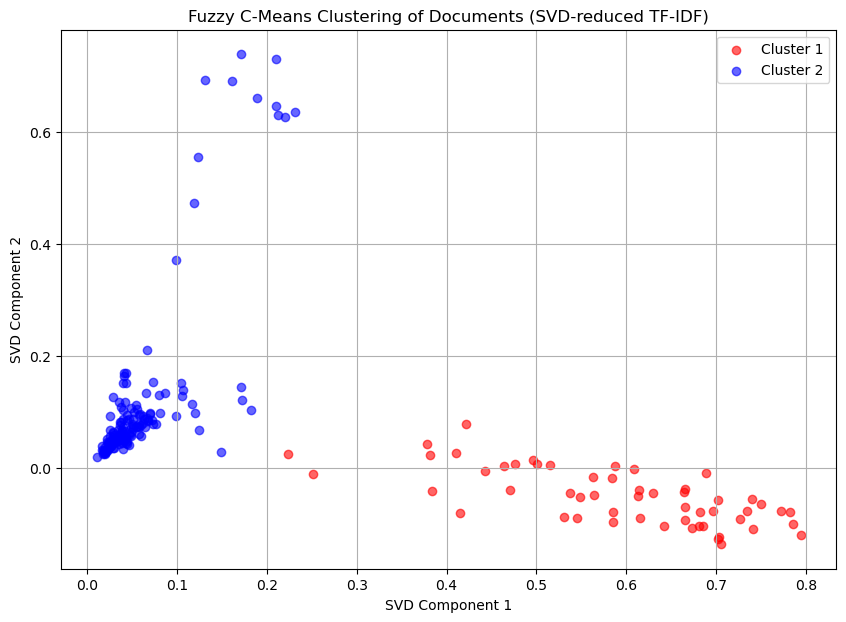

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# Step 1: Reduce dimensions of TF-IDF data to 2D using SVD
svd = TruncatedSVD(n_components=2, random_state=42)
tfidf_2d = svd.fit_transform(tfidf_array)

# Step 2: Plotting the clusters
plt.figure(figsize=(10, 7))

# Assign colors based on cluster labels
colors = ['red', 'blue']
for cluster in range(2):
    plt.scatter(
        tfidf_2d[hard_labels == cluster, 0], 
        tfidf_2d[hard_labels == cluster, 1],
        color=colors[cluster], 
        label=f'Cluster {cluster + 1}', 
        alpha=0.6
    )

# Step 3: Label and show plot
plt.title("Fuzzy C-Means Clustering of Documents (SVD-reduced TF-IDF)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score using the TF-IDF array and hard cluster labels
silhouette_avg = silhouette_score(tfidf_array, hard_labels)

# Display the Silhouette Score
print(f"Silhouette Score for Fuzzy C-Means Clustering: {silhouette_avg:.4f}")


Silhouette Score for Fuzzy C-Means Clustering: 0.0484


In [23]:
import numpy as np

# Mendapatkan indeks dokumen untuk setiap kluster
cluster_0_docs = np.where(hard_labels == 0)[0]
cluster_1_docs = np.where(hard_labels == 1)[0]

# Menghitung rata-rata TF-IDF untuk setiap kata di setiap kluster
tfidf_cluster_0 = tfidf_matrix[cluster_0_docs].mean(axis=0).A1
tfidf_cluster_1 = tfidf_matrix[cluster_1_docs].mean(axis=0).A1

# Mendapatkan fitur kata
terms = tfidf_vectorizer.get_feature_names_out()

# Mengambil 10 term teratas untuk masing-masing kluster
top_terms_cluster_0 = [terms[i] for i in tfidf_cluster_0.argsort()[-10:][::-1]]
top_terms_cluster_1 = [terms[i] for i in tfidf_cluster_1.argsort()[-10:][::-1]]

print("Top terms in Cluster 0:", top_terms_cluster_0)
print("Top terms in Cluster 1:", top_terms_cluster_1)

Top terms in Cluster 0: ['israel', 'lebanon', 'hizbullah', 'serang', 'militer', 'tewas', 'gaza', 'perang', 'orang', 'warga']
Top terms in Cluster 1: ['ukraina', 'rusia', 'presiden', 'baca', 'orang', 'indonesia', 'temu', 'negara', 'hujan', 'zelensky']


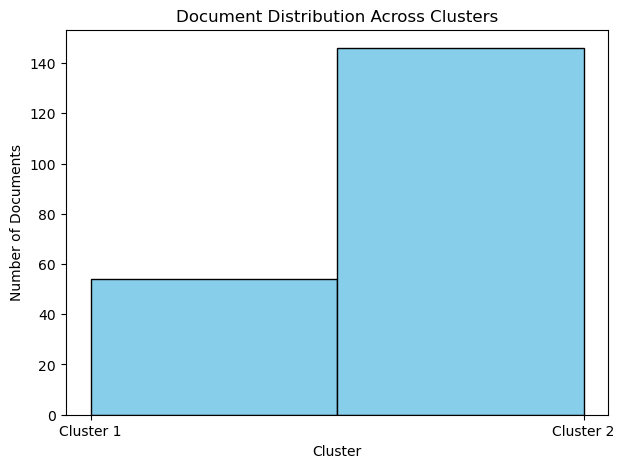

In [29]:
# Visualisasi distribusi dokumen dalam setiap kluster
plt.figure(figsize=(7, 5))
plt.hist(hard_labels, bins=2, color='skyblue', edgecolor='black')  # Gunakan satu warna saja
plt.title("Document Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.xticks([0, 1], ['Cluster 1', 'Cluster 2'])
plt.show()


In [42]:
import pickle
import pandas as pd

# Simpan model FCM menggunakan pickle
with open("fcm_model_new.pkl", "wb") as file:
    pickle.dump(fcm, file)

# Simpan hasil clustering ke file CSV
cluster_results.to_csv("cluster_results.csv", index=False)

Link Deployment Aplikasi Clustering Berita :

https://huggingface.co/spaces/drhadityo9/cluster_news_dohan